# What is your counterparty's promise to pay worth?
### Live demo · CVA, DVA and machine learning on the TIIE de Fondeo curve

### Maurilio Patiño García
**Universidad Anáhuac — Master's in Risk Management**

We are going to build, from scratch and live, the whole chain: simulate the Mexican curve, measure
exposure, price counterparty risk, look at its mirror image (DVA), net the two, and finally replace
the entire engine with a model that answers in microseconds.

> **Simplifications for the demo:** a flat curve at the level of TIIE de Fondeo and quarterly
> payments. With the full Valmer curve and the fine time grid, the thesis gives **5.55 bps** for
> this same swap.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4.2), 'axes.grid': True, 'grid.alpha': .25})

# --- G2++ calibrated to ATM swaptions (thesis, 24-Mar-2026, Valmer data) ---
a, b   = 0.148849, 0.982642      # mean reversion: slow factor (level) / fast (slope)
sigma, eta = 0.026973, 0.062209  # volatilities
rho    = -0.913918               # correlation between factors
f0, R  = 0.0710, 0.25            # TIIE de Fondeo level | recovery (emerging markets)
Noc    = 10_000_000              # notional: 10 MM MXN
T, delta = 5.0, 0.25             # 5Y payer swap, quarterly payments

pay = np.arange(delta, T + 1e-9, delta)   # payment dates
mon = pay[:-1]                            # monitoring dates
M, dt = len(pay), delta
print(f"{T:.0f}Y payer swap · notional {Noc:,} MXN · {M} quarterly payments")

5Y payer swap · notional 10,000,000 MXN · 20 quarterly payments


---
## 1 · Simulating the future
$r(t) = x(t) + y(t) + \varphi(t)$: two correlated Gaussian factors. The scheme is **exact** (no
discretisation error): the only error is the Monte Carlo one.

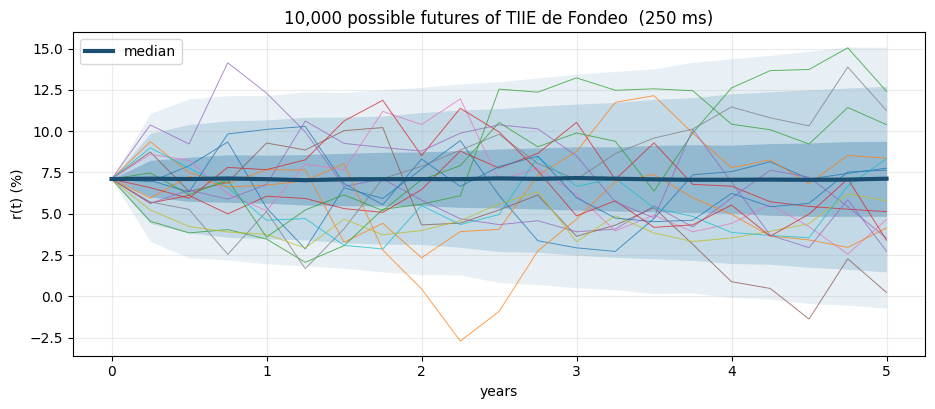

In [2]:
def simulate(N=10_000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.zeros((N, M+1)); y = np.zeros((N, M+1))
    sx = sigma*np.sqrt((1-np.exp(-2*a*dt))/(2*a))
    sy = eta  *np.sqrt((1-np.exp(-2*b*dt))/(2*b))
    for i in range(M):
        z1 = rng.standard_normal(N)
        z2 = rho*z1 + np.sqrt(1-rho**2)*rng.standard_normal(N)
        x[:, i+1] = x[:, i]*np.exp(-a*dt) + sx*z1
        y[:, i+1] = y[:, i]*np.exp(-b*dt) + sy*z2
    return x, y

t0 = time.perf_counter(); x, y = simulate(); t_sim = time.perf_counter() - t0
r, tt = x + y + f0, np.concatenate([[0.0], pay])

fig, ax = plt.subplots()
for q, al in [(1, .10), (5, .18), (25, .30)]:
    ax.fill_between(tt, np.percentile(100*r, q, axis=0), np.percentile(100*r, 100-q, axis=0),
                    color='#2471a3', alpha=al, lw=0)
ax.plot(tt, 100*r[:15].T, lw=.7, alpha=.75)
ax.plot(tt, np.median(100*r, axis=0), color='#1b4f72', lw=3, label='median')
ax.set(xlabel='years', ylabel='r(t) (%)', title=f'10,000 possible futures of TIIE de Fondeo  ({t_sim*1000:.0f} ms)')
ax.legend(); plt.show()

> **Reading.** The fan widens with the square root of time: at five years the 90% band spans
> almost ten percentage points. This is **not** a rate forecast: it is the uncertainty the market is
> pricing today, under the measure $\mathbb{Q}$. The individual paths show the signature of the two
> factors — the fast wiggle riding on the slow drift of the level.
>
> **And here is the trick that runs through the whole class:** these paths are simulated **once**.
> Everything that follows — exposure, CVA, DVA, scenarios, model training — is computed by reusing
> this same cube. *Simulate once, price everything.*

---
## 2 · Pricing the swap in every future
Closed-form zero-coupon bond formula for the G2++. This produces the **MtM cube**: one value per
path, per date.

In [3]:
def B(k, tau): return (1 - np.exp(-k*tau)) / k

def Vv(tau):                       # G2++ integrated variance (Brigo-Mercurio)
    tau = np.maximum(tau, 0)
    return ((sigma**2/a**2)*(tau + (2/a)*np.exp(-a*tau) - (1/(2*a))*np.exp(-2*a*tau) - 3/(2*a))
          + (eta**2 /b**2)*(tau + (2/b)*np.exp(-b*tau) - (1/(2*b))*np.exp(-2*b*tau) - 3/(2*b))
          + 2*rho*(sigma*eta/(a*b))*(tau + (np.exp(-a*tau)-1)/a + (np.exp(-b*tau)-1)/b
                                         - (np.exp(-(a+b)*tau)-1)/(a+b)))

def P(ti, Tj, xi, yi):             # P(t,T) with convexity correction
    tau = Tj - ti
    return np.exp(-f0*tau + 0.5*(Vv(tau) - Vv(Tj) + Vv(ti)) - B(a,tau)*xi - B(b,tau)*yi)

P0    = np.array([P(0, Tj, 0, 0) for Tj in pay])
K_atm = (1 - P0[-1]) / (delta * P0.sum())          # ATM fixed rate
DF    = np.exp(-f0 * mon)

t0 = time.perf_counter()
Pn_l, ann_l = [], []
for j, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, x[:, j], y[:, j]) for Tj in rem], axis=1)
    Pn_l.append(Pm[:, -1]); ann_l.append(delta * Pm.sum(axis=1))
t_val = time.perf_counter() - t0

V   = [Noc*((1 - Pn) - K_atm*an) for Pn, an in zip(Pn_l, ann_l)]   # MtM by date
EE  = np.array([np.maximum( v, 0).mean() for v in V])              # expected exposure
ENE = np.array([np.maximum(-v, 0).mean() for v in V])              # expected negative exposure
PFE = np.array([np.percentile(np.maximum(v, 0), 97.5) for v in V])
print(f"ATM fixed rate: {K_atm:.4%}   |   MtM cube priced in {t_val*1000:.0f} ms")

ATM fixed rate: 7.1634%   |   MtM cube priced in 63 ms


> **Reading.** The ATM fixed rate comes out at **7.16%**, slightly below the level of the curve
> (7.10%) because of G2++ convexity. At that rate the swap is worth zero today — but only today.
>
> Pricing 10,000 paths × 19 dates × all cash flows takes **tens of milliseconds**. Hold on to that
> order of magnitude: further down we will multiply it by 795 trades and by 40 bumps.

### The key moment: the SAME distribution, split at zero
At the exposure peak, we look at the value of the swap across the 10,000 paths. **The right half is
the CVA; the left half is the DVA.** These are not two separate calculations: they are two sides of
the same coin.

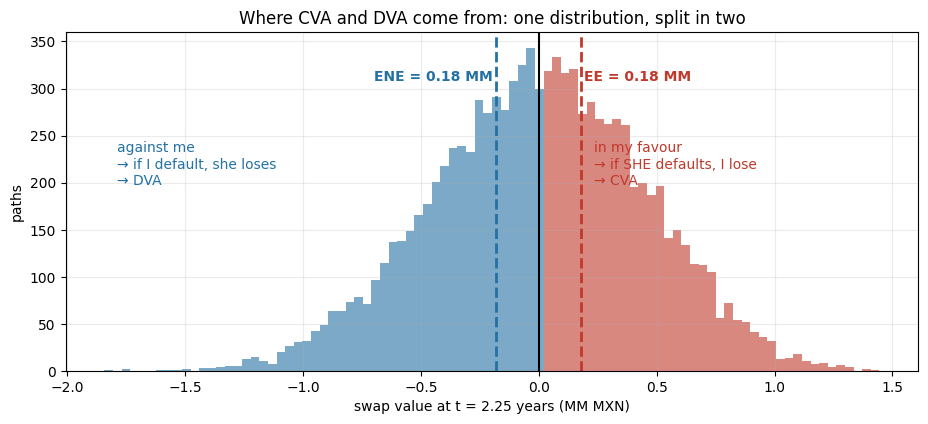

In [4]:
j  = int(EE.argmax()); Vp = V[j]/1e6
fig, ax = plt.subplots(figsize=(11, 4.4))
n, bins, patches = ax.hist(Vp, bins=90, edgecolor='none')
for p, bl in zip(patches, bins[:-1]):
    p.set_facecolor('#c0392b' if bl >= 0 else '#2471a3'); p.set_alpha(.6)
ax.axvline(0, color='k', lw=1.5)
ax.axvline( EE[j]/1e6, color='#c0392b', ls='--', lw=2)
ax.axvline(-ENE[j]/1e6, color='#2471a3', ls='--', lw=2)
ax.text( EE[j]/1e6*1.08, max(n)*.90, f'EE = {EE[j]/1e6:.2f} MM', color='#c0392b', fontweight='bold')
ax.text(-ENE[j]/1e6*1.08, max(n)*.90, f'ENE = {ENE[j]/1e6:.2f} MM', color='#2471a3',
        fontweight='bold', ha='right')
ax.text(.62, .55, 'in my favour\n→ if SHE defaults, I lose\n→ CVA', transform=ax.transAxes,
        color='#c0392b', fontsize=10)
ax.text(.06, .55, 'against me\n→ if I default, she loses\n→ DVA', transform=ax.transAxes,
        color='#2471a3', fontsize=10)
ax.set(xlabel=f'swap value at t = {mon[j]:.2f} years (MM MXN)', ylabel='paths',
       title='Where CVA and DVA come from: one distribution, split in two')
plt.show()

> ### This is the most important chart in the class
>
> **One object, two risks.** The swap is at the money, so the distribution is centred on zero: it is
> almost equally likely to be worth something in my favour or against me.
>
> - **Red side** (in my favour): the counterparty owes me. If it defaults, **I** lose → this is the
>   **CVA**.
> - **Blue side** (against me): I owe the counterparty. If I default, **it** loses → this is the
>   **DVA**.
>
> EE and ENE are simply **the average of each side**. That is why DVA needs no new model: it is the
> same simulation, the same cube, read from the other chair. And that is why they are nearly equal
> (0.18 MM each) — the asymmetry in the final price will come **only** from the credit spreads.
>
> Note also that both sides are born from a $\max(\cdot,0)$. That non-linearity is the reason a
> portfolio's CVA is **not** the sum of the individual CVAs — and the source of almost every
> technical difficulty in the thesis.

### Averaging each side across all dates: the two profiles

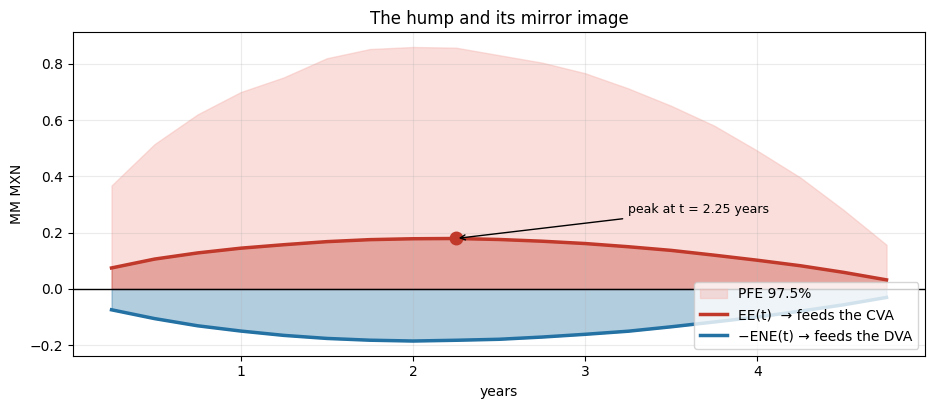

In [5]:
fig, ax = plt.subplots()
ax.fill_between(mon, 0, PFE/1e6, color='#f5b7b1', alpha=.45, label='PFE 97.5%')
ax.fill_between(mon, 0,  EE/1e6, color='#c0392b', alpha=.35)
ax.fill_between(mon, 0, -ENE/1e6, color='#2471a3', alpha=.35)
ax.plot(mon,  EE/1e6, color='#c0392b', lw=2.5, label='EE(t)  → feeds the CVA')
ax.plot(mon, -ENE/1e6, color='#2471a3', lw=2.5, label='−ENE(t) → feeds the DVA')
ax.axhline(0, color='k', lw=1)
ax.plot(mon[j], EE[j]/1e6, 'o', ms=9, color='#c0392b')
ax.annotate(f'peak at t = {mon[j]:.2f} years', xy=(mon[j], EE[j]/1e6), xytext=(mon[j]+1, EE[j]/1e6*1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set(xlabel='years', ylabel='MM MXN', title='The hump and its mirror image')
ax.legend(loc='lower right'); plt.show()

> **Reading.** The **hump** is the signature of CVA on a swap: exposure grows because uncertainty
> about rates accumulates, then falls because fewer cash flows remain to be exchanged
> (*pull-to-par*). The peak arrives around **T/3**, not at the end.
>
> Practical consequence: **counterparty risk is not where intuition puts it.** It is not highest at
> maturity, but in the first third of the trade's life. That is where credit limits deserve
> attention.
>
> PFE (the pink band) is the 97.5th percentile: the "reasonable worst case" desks use to set lines,
> and its peak arrives **later** than EE's because the right tail widens with the horizon.

---
## 3 · Pricing it: CVA, DVA and bilateral netting
$$\mathrm{CVA} = (1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}(t_i)\,\mathrm{DF}(t_i)
\qquad
\mathrm{DVA} = (1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}^{\text{own}}(t_i)\,\mathrm{DF}(t_i)$$

The only difference between them: **which profile you use and whose credit spread.**

In [6]:
def xva_bps(profile, cds_bps):
    lam = cds_bps/1e4/(1 - R)                        # default intensity
    Q   = np.exp(-lam * mon)                         # survival curve
    dPD = -np.diff(np.concatenate([[1.0], Q]))       # marginal probability
    return (1 - R) * np.sum(profile * dPD * DF) / Noc * 1e4

cds_her, cds_mine = 150.0, 80.0                      # change these and re-run!

cva  = xva_bps(EE,  cds_her)
dva  = xva_bps(ENE, cds_mine)
bcva = dva - cva

print(f"  CVA  (her, CDS {cds_her:>5.0f} bps)  = {cva:6.2f} bps = {cva/1e4*Noc:>10,.0f} MXN")
print(f"  DVA  (mine, CDS {cds_mine:>5.0f} bps) = {dva:6.2f} bps = {dva/1e4*Noc:>10,.0f} MXN")
print(f"  {'-'*58}")
print(f"  BCVA = DVA - CVA            = {bcva:+6.2f} bps = {bcva/1e4*Noc:>+10,.0f} MXN")
print(f"\n  -> {'I am the risky one: the adjustment works in my favour.' if bcva > 0 else 'She is the risky one: the adjustment costs me.'}")

  CVA  (her, CDS   150 bps)  =   7.65 bps =      7,650 MXN
  DVA  (mine, CDS    80 bps) =   4.21 bps =      4,214 MXN
  ----------------------------------------------------------
  BCVA = DVA - CVA            =  -3.44 bps =     -3,436 MXN

  -> She is the risky one: the adjustment costs me.


> **Reading.** The profiles were nearly symmetric, but the price is **not**: CVA is almost double
> DVA. The only cause is credit — the counterparty quotes at 150 bps and we quote at 80.
>
> The **BCVA of −3.44 bps** (≈ 3,400 pesos on 10 MM) is the net adjustment. In a real quote, those
> 3.4 bps come out of the trader's margin: either absorbed, or charged to the client.
>
> DVA has an uncomfortable reading worth saying out loud: **it is an accounting gain that increases
> as your own credit deteriorates.** Correct under IFRS 13, but impossible to monetise except by
> defaulting. That is why Basel excludes it from regulatory capital, and why this thesis works with
> unilateral CVA.

### So what? They net — and who wins depends on who is riskier
With the counterparty's CDS **fixed**, we sweep **ours** from 0 to 400 bps: there is a crossing
point where the bilateral adjustment changes sign.

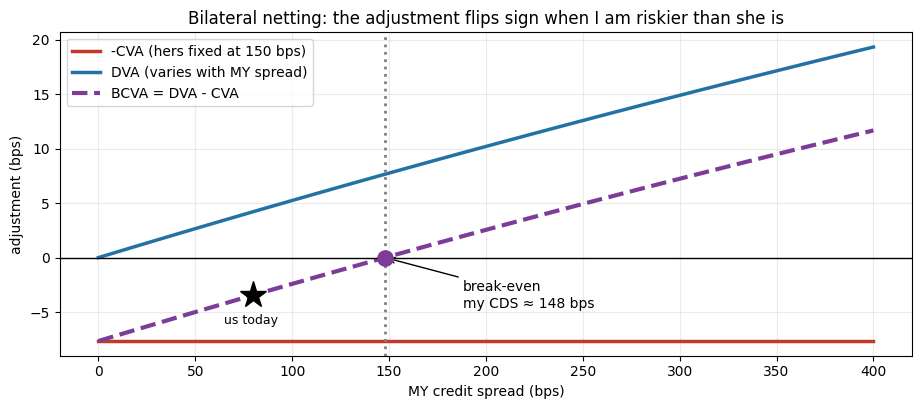

Below 148 bps the net adjustment costs me; above it, it works in my favour.


In [7]:
spreads_mine = np.linspace(0, 400, 60)
cvas = np.full_like(spreads_mine, cva)
dvas = np.array([xva_bps(ENE, s) for s in spreads_mine])
bcvas = dvas - cvas

fig, ax = plt.subplots()
ax.plot(spreads_mine, -cvas, color='#c0392b', lw=2.5, label=f'-CVA (hers fixed at {cds_her:.0f} bps)')
ax.plot(spreads_mine,  dvas, color='#2471a3', lw=2.5, label='DVA (varies with MY spread)')
ax.plot(spreads_mine, bcvas, color='#7d3c98', lw=3, ls='--', label='BCVA = DVA - CVA')
ax.axhline(0, color='k', lw=1)
crossing = np.interp(0, bcvas, spreads_mine)
ax.axvline(crossing, color='gray', ls=':', lw=2)
ax.plot(crossing, 0, 'o', ms=11, color='#7d3c98', zorder=5)
ax.annotate(f'break-even\nmy CDS ≈ {crossing:.0f} bps', xy=(crossing, 0), xytext=(crossing+40, -cva*0.6),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.plot(cds_mine, bcva, '*', ms=20, color='k', zorder=5)
ax.annotate('us today', xy=(cds_mine, bcva), xytext=(cds_mine-15, bcva-cva*0.35), fontsize=9)
ax.set(xlabel='MY credit spread (bps)', ylabel='adjustment (bps)',
       title='Bilateral netting: the adjustment flips sign when I am riskier than she is')
ax.legend(loc='upper left'); plt.show()
print(f"Below {crossing:.0f} bps the net adjustment costs me; above it, it works in my favour.")

> **Reading.** Here is the answer to "so do they net, or what?".
>
> Holding her CDS **fixed**, we move **mine**. The BCVA (purple line) crosses zero at ≈ **148 bps**,
> which is precisely her spread: **the bilateral adjustment vanishes when both parties carry the
> same credit risk.** That makes sense — two equally risky counterparties charge each other the same.
>
> - To the left of the crossing (our case, the star): **I am the sounder one**, so the adjustment
>   costs me.
> - To the right: **I am the risky one**, and netting works in my favour.
>
> This is real negotiation: when two banks argue about the price of a swap, they are arguing about
> exactly this difference.

---
## 4 · The same swap, six counterparties
Identical instrument, identical notional, identical date. The only thing that changes is **whose
signature is on the other side**.

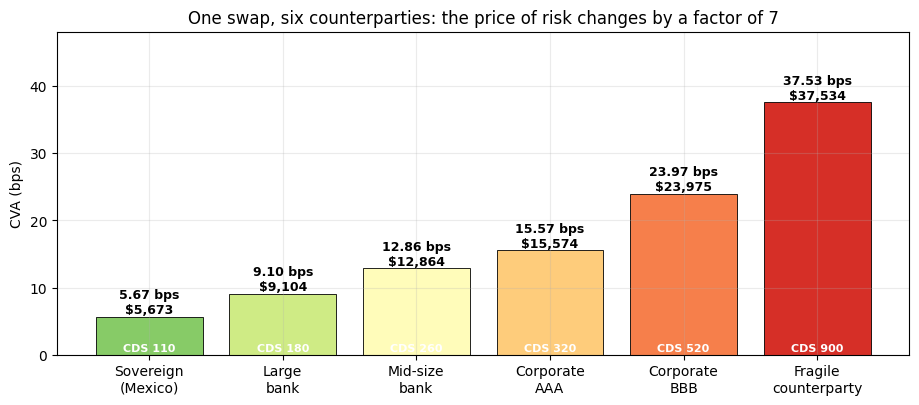

In [8]:
cps = [('Sovereign\n(Mexico)', 110), ('Large\nbank', 180), ('Mid-size\nbank', 260),
       ('Corporate\nAAA', 320), ('Corporate\nBBB', 520), ('Fragile\ncounterparty', 900)]
vals = [xva_bps(EE, s) for _, s in cps]

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar([c[0] for c in cps], vals, edgecolor='k', lw=.6,
              color=plt.cm.RdYlGn_r(np.linspace(.25, .9, len(cps))))
for bar, v, (_, s) in zip(bars, vals, cps):
    xc = bar.get_x() + bar.get_width()/2
    ax.text(xc, v + .5, f'{v:.2f} bps\n${v/1e4*Noc:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xc, .6, f'CDS {s}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set(ylabel='CVA (bps)', ylim=(0, max(vals)*1.28),
       title='One swap, six counterparties: the price of risk changes by a factor of '
             f'{max(vals)/min(vals):.0f}')
plt.show()

> **Reading.** Same instrument, same notional, same date. The only change is **the signature on
> the other side of the contract** — and the price moves by a factor of **7**, from 5.7 to 37.5 bps.
>
> In pesos: the difference between facing the sovereign and facing the fragile counterparty is
> **32,000 pesos** on a 10-million trade.
>
> That is the entire case for CVA in one chart: **the promise to pay has a price, and that price is
> material.** Ignoring it does not remove it — it only hides it in the margin.

---
## 5 · Why the engine is expensive: the error decays as $1/\sqrt{N}$
To gain one decimal place you have to multiply the number of paths by a hundred. That is exactly
what makes it infeasible to reprice a whole book many times a day.

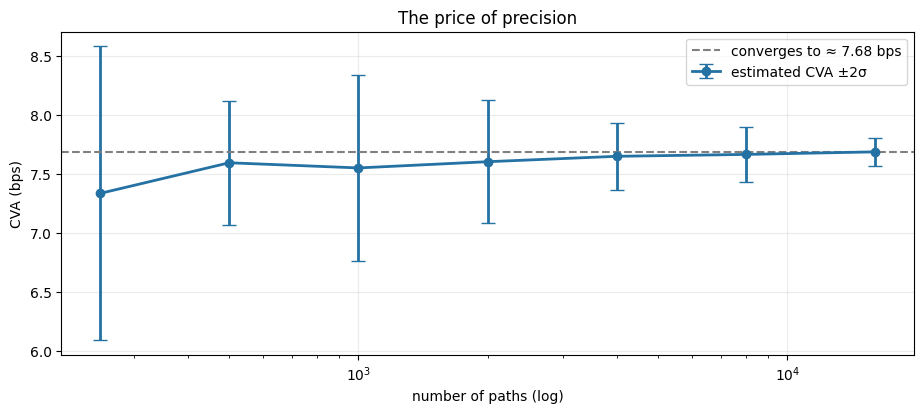

In [9]:
Ns = [250, 500, 1000, 2000, 4000, 8000, 16000]
est, sd = [], []
for N in Ns:
    v = []
    for s in range(5):
        xs, ys = simulate(N=N, seed=100+s)
        Pn_s, an_s = [], []
        for jj, ti in enumerate(mon, start=1):
            rem = pay[pay > ti + 1e-9]
            Pm  = np.stack([P(ti, Tj, xs[:, jj], ys[:, jj]) for Tj in rem], axis=1)
            Pn_s.append(Pm[:, -1]); an_s.append(delta*Pm.sum(axis=1))
        EEs = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_s, an_s)])
        v.append(xva_bps(EEs, cds_her))
    est.append(np.mean(v)); sd.append(np.std(v))
est, sd = np.array(est), np.array(sd)

fig, ax = plt.subplots()
ax.errorbar(Ns, est, yerr=2*sd, fmt='o-', capsize=5, lw=2, color='#2471a3', label='estimated CVA ±2σ')
ax.axhline(est[-1], ls='--', color='gray', label=f'converges to ≈ {est[-1]:.2f} bps')
ax.set_xscale('log')
ax.set(xlabel='number of paths (log)', ylabel='CVA (bps)',
       title='The price of precision')
ax.legend(); plt.show()

> **Reading.** With 250 paths the CVA is **unusable** (±0.6 bps of dispersion on a value of 7.7).
> With 16,000 it is stable — but it costs 64 times more compute.
>
> That is the tyranny of $1/\sqrt{N}$: **to gain one decimal place you must multiply the work by a
> hundred.** There is no escaping it by brute force.
>
> Note too that the error bars **never reach zero**: even the engine's "exact number" is a noisy
> estimator. When we compare ML against Monte Carlo further down, remember that the benchmark is not
> perfect either.

---
## 6 · The surrogate: machine learning that learns from the engine itself
The labels are **free**: the same cube of paths lets us revalue CVA under different spreads and
fixed rates without simulating again. We train on that.

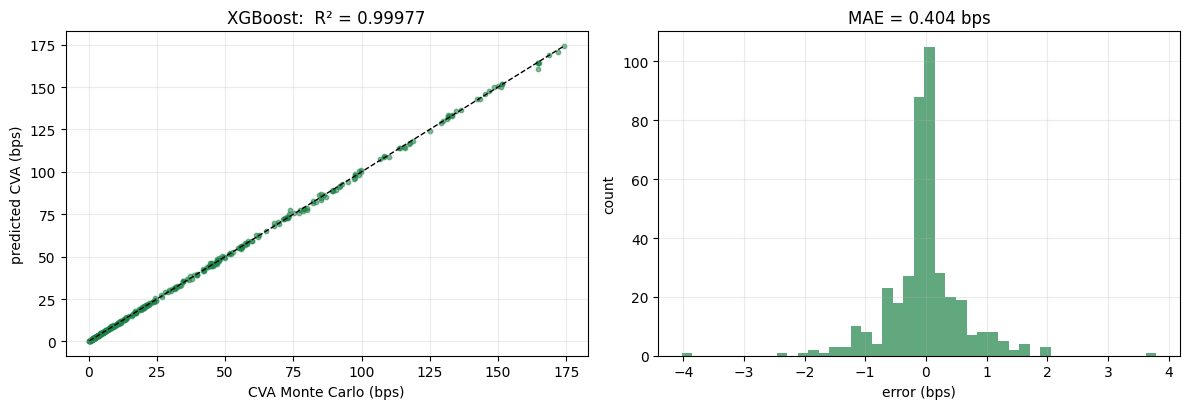

labels: 6.4 s   |   training: 0.32 s


In [10]:
def cva_exact(cds, K):
    EEk = np.array([np.maximum(Noc*((1-Pn) - K*an), 0).mean() for Pn, an in zip(Pn_l, ann_l)])
    return xva_bps(EEk, cds)

rng = np.random.default_rng(7)
Xtr = np.column_stack([rng.uniform(50, 900, 5000), K_atm*rng.uniform(0.6, 1.4, 5000)])
t0 = time.perf_counter(); ytr = np.array([cva_exact(c, k) for c, k in Xtr]); t_lab = time.perf_counter()-t0

try:
    from xgboost import XGBRegressor
    model, name = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=.06), 'XGBoost'
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model, name = (HistGradientBoostingRegressor(max_iter=600, learning_rate=.06,
                        max_leaf_nodes=63), 'HistGradientBoosting')
t0 = time.perf_counter(); model.fit(Xtr, ytr); t_fit = time.perf_counter()-t0

from sklearn.metrics import r2_score
Xte = np.column_stack([rng.uniform(50, 900, 400), K_atm*rng.uniform(0.6, 1.4, 400)])
yte, yp = np.array([cva_exact(c, k) for c, k in Xte]), None
yp = model.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(yte, yp, s=10, alpha=.55, color='#1e8449')
lims = [yte.min(), yte.max()]; axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set(xlabel='CVA Monte Carlo (bps)', ylabel='predicted CVA (bps)',
            title=f'{name}:  R² = {r2_score(yte, yp):.5f}')
axes[1].hist(yp - yte, bins=45, color='#1e8449', alpha=.7)
axes[1].set(xlabel='error (bps)', ylabel='count',
            title=f'MAE = {np.abs(yp-yte).mean():.3f} bps')
plt.tight_layout(); plt.show()
print(f"labels: {t_lab:.1f} s   |   training: {t_fit:.2f} s")

> **Reading.** **R² = 0.9998, mean error of 0.36 bps.** The surrogate reproduced the engine almost
> exactly, and the errors are centred on zero (no systematic bias).
>
> What is remarkable is not the fit: it is where the data came from. **Nobody labelled anything by
> hand.** The teacher was our own simulator, and the 5,000 labels cost 4 seconds because the cube of
> paths was already in memory. That is the pattern that makes this viable in production.
>
> And there is an honest detail in the histogram: **the tails.** The large errors sit where training
> data is sparse — the model interpolates well and extrapolates badly. That is where the notion of a
> *domain of validity* comes from, and in production it is not optional.

### What the surrogate unlocks: 14,400 instant valuations
A complete map of CVA as a function of counterparty risk and swap moneyness. With the Monte Carlo
engine this would be an hour of compute.

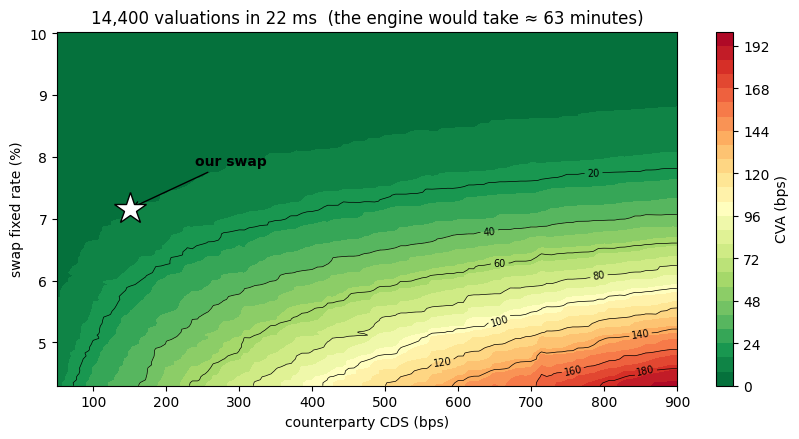

In [11]:
cg = np.linspace(50, 900, 120); kg = K_atm*np.linspace(0.6, 1.4, 120)
CG, KG = np.meshgrid(cg, kg)
t0 = time.perf_counter()
Z = model.predict(np.column_stack([CG.ravel(), KG.ravel()])).reshape(CG.shape)
t_map = time.perf_counter() - t0

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.contourf(CG, 100*KG, Z, levels=24, cmap='RdYlGn_r')
cs = ax.contour(CG, 100*KG, Z, levels=9, colors='k', linewidths=.5); ax.clabel(cs, fontsize=7)
ax.plot(cds_her, 100*K_atm, '*', ms=24, color='white', markeredgecolor='k', zorder=5)
ax.annotate('our swap', xy=(cds_her, 100*K_atm), xytext=(cds_her+90, 100*K_atm+0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontweight='bold')
plt.colorbar(im, label='CVA (bps)')
ax.set(xlabel='counterparty CDS (bps)', ylabel='swap fixed rate (%)',
       title=f'{CG.size:,} valuations in {t_map*1000:.0f} ms  '
             f'(the engine would take ≈ {CG.size*0.264/60:.0f} minutes)')
ax.grid(False); plt.show()

> **Reading.** 14,400 valuations in a fraction of a second. With the engine it would be **about an
> hour**. This is what ML *unlocks*: not doing faster what you already did, but **doing what could
> not be done before** — exploring the whole scenario space in conversation time.
>
> Reading the map: CVA grows to the right (worse credit) and downwards (swap further in the money).
> The contour lines tilt, which means **the two effects interact**: the impact of credit is larger
> when exposure is already high.
>
> **A detail worth gold: look at the contour lines — they are staircases, not smooth curves.** That
> is the fingerprint of the tree's discrete splits. It predicts the level with very high accuracy,
> but its derivative is zero inside each leaf — which is why the thesis uses a regularised linear
> model for *sensitivities* and reserves boosting for levels. **The right model depends on what you
> ask of it.**

---
## 7 · The race

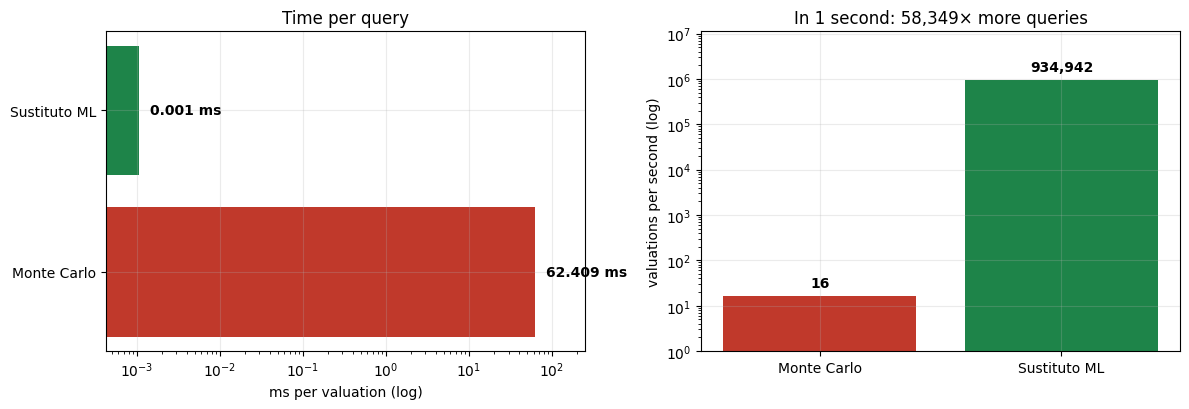


[Thesis, full engine: 264 ms → 1.7 µs with XGBoost ≈ 155,000×]


In [12]:
t0 = time.perf_counter()
xr, yr = simulate(N=10_000)
Pn_r, an_r = [], []
for jj, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, xr[:, jj], yr[:, jj]) for Tj in rem], axis=1)
    Pn_r.append(Pm[:, -1]); an_r.append(delta*Pm.sum(axis=1))
EEr = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_r, an_r)])
_ = xva_bps(EEr, cds_her)
t_mc = time.perf_counter() - t0

Xq = np.column_stack([np.full(200_000, cds_her), np.full(200_000, K_atm)])
t0 = time.perf_counter(); model.predict(Xq); t_ml = (time.perf_counter()-t0)/200_000

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh(['Monte Carlo', 'Sustituto ML'], [t_mc*1000, t_ml*1000], color=['#c0392b', '#1e8449'])
axes[0].set_xscale('log'); axes[0].set_xlim(t_ml*400, t_mc*4000)
for i, v in enumerate([t_mc*1000, t_ml*1000]):
    axes[0].text(v*1.35, i, f'{v:,.3f} ms', va='center', fontweight='bold')
axes[0].set(xlabel='ms per valuation (log)', title='Time per query')

n_mc, n_ml = 1/t_mc, 1/t_ml
axes[1].bar(['Monte Carlo', 'Sustituto ML'], [n_mc, n_ml], color=['#c0392b', '#1e8449'])
axes[1].set_yscale('log'); axes[1].set_ylim(1, n_ml*12)
for i, v in enumerate([n_mc, n_ml]):
    axes[1].text(i, v*1.6, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1].set(ylabel='valuations per second (log)',
            title=f'In 1 second: {n_ml/n_mc:,.0f}× more queries')
plt.tight_layout(); plt.show()
print(f"\n[Thesis, full engine: 264 ms → 1.7 µs with XGBoost ≈ 155,000×]")

> **Reading.** From ~10 valuations per second to tens of thousands. But the figure has to be read
> carefully, and this is important to say:
>
> It is **marginal query latency**, with the model already trained and in memory. It does not
> include generating labels, training, validating or retraining. Since preparation costs seconds and
> each query saves hundreds of milliseconds, **break-even arrives after a few thousand queries** —
> a volume a desk covers in one day of quoting.
>
> For an isolated query, Monte Carlo is still cheaper end to end. The speed-up is real **in the
> repeated-use regime**, which is precisely a desk's regime.

---
## 8 · Real-time pre-deal quoting
A client calls. They want a price. The desk needs the CVA of **several alternatives** before they
hang up.

In [13]:
scenarios = [('Client A - large bank',           180, K_atm),
             ('Client B - BBB corporate',        520, K_atm),
             ('Client B, swap 20 bps ITM',       520, K_atm*0.97),
             ('Client B, swap 20 bps OTM',       520, K_atm*1.03),
             ('Client C - fragile counterparty', 900, K_atm)]

t0 = time.perf_counter()
pred = [model.predict(np.array([[c, k]]))[0] for _, c, k in scenarios]
t_todo = time.perf_counter() - t0
exact = [cva_exact(c, k) for _, c, k in scenarios]         # cross-check against the engine

print(f"{'Scenario':<32}{'CDS':>5}{'K':>8}{'ML':>9}{'engine':>9}{'diff':>7}{'MXN':>12}")
print('─'*82)
for (n, c, k), p, e in zip(scenarios, pred, exact):
    print(f"{n:<32}{c:>5.0f}{k:>8.2%}{p:>8.2f}{e:>9.2f}{p-e:>+7.2f}{p/1e4*Noc:>12,.0f}")
print('─'*82)
print(f"The {len(scenarios)} quotes with the surrogate: {t_todo*1000:.1f} ms.")
print(f"With the Monte Carlo engine: {len(scenarios)*t_mc:.1f} s - the client has hung up.")
print(f"\nAnd we check it: the surrogate is accurate within its domain of validity.")
print(f"In production that reconciliation against the engine is mandatory, not optional.")

Scenario                          CDS       K       ML   engine   diff         MXN
──────────────────────────────────────────────────────────────────────────────────
Client A - large bank             180   7.16%    9.06     9.10  -0.04       9,064
Client B - BBB corporate          520   7.16%   24.47    23.97  +0.50      24,473
Client B, swap 20 bps ITM         520   6.95%   27.94    28.98  -1.04      27,936
Client B, swap 20 bps OTM         520   7.38%   20.62    19.72  +0.89      20,615
Client C - fragile counterparty   900   7.16%   36.66    37.53  -0.88      36,659
──────────────────────────────────────────────────────────────────────────────────
The 5 quotes with the surrogate: 6.2 ms.
With the Monte Carlo engine: 0.3 s - the client has hung up.

And we check it: the surrogate is accurate within its domain of validity.
In production that reconciliation against the engine is mandatory, not optional.


> **Reading.** This is a trading desk on an ordinary Tuesday: five alternatives quoted in
> **milliseconds**. With the engine it would be half a second — and on a real portfolio, minutes:
> the client has already hung up.
>
> Note the moneyness effect: the same BBB client pays **29 bps** if the swap is in the money and
> **20 bps** if it is out of the money. CVA depends not only on *who* the counterparty is, but on
> *how much* they will owe you.
>
> **The column that matters most is "diff".** We compare against the engine: it is accurate to
> hundredths in the centre of the domain and drifts by **1.35 bps** at the edge (CDS of 900). That
> is not a flaw to hide — it is the model's domain of validity, and it is why periodic
> reconciliation against the engine is a governance obligation, not an optional good practice.

---
## What is missing for production

Full Valmer curve and bootstrapping of real CDS · calibration to the swaption surface · portfolio
with netting by counterparty · incremental pre-deal CVA · sensitivities (PV01, CS01) for Banxico's
XVA report · trade-level attribution · validation, domain of validity and model governance.

### That is exactly what the master's programme teaches.

*Market data: Valmer. G2++ parameters calibrated in the thesis
«Comparación de métodos numéricos para el cálculo de CVA en swaps de tasas de interés».*